# Sampling


## Imports


In [8]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from src.sampler_utils import (
    atoms_to_structures,
    load_reduced,
    pc_coverage_bins_auto,
    sample,
    sample_to_coverage,
    sample_to_coverage_seeded_batches,
)
from src.plots_exports_utils import plot_sampling_pca, export_selected_structures
from src.workflow_config import ensure_directory


## Inputs


In [9]:
# X can be the original standardized SOAP or a reduced matrix (e.g., PCA)
embedded_file = True
if embedded_file:
    embedding_dir = Path("embedding")
    npy_files = sorted(embedding_dir.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError("No .npy file found in embedding/")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using embedding: {npy_file}")
    X = load_reduced(npy_file)
    print("Loaded embedding with shape:", X.shape)
else:
    npy_files = sorted(Path(".").glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError("No .npy file found in current directory")
    if len(npy_files) > 1:
        raise RuntimeError(f"Multiple .npy files found: {npy_files}")
    npy_file = npy_files[0]
    print(f"Using standardized SOAP matrix: {npy_file}")
    X = load_reduced(npy_file)

desc_dir = Path("desc")
provenance_files = list(desc_dir.glob("*.parquet")) + list(desc_dir.glob("*.csv"))
if not provenance_files:
    raise FileNotFoundError("No provenance table found in desc/")
provenance_files = sorted(provenance_files)
provenance_file = next((p for p in provenance_files if p.suffix == ".parquet"), provenance_files[0])
print(f"Using provenance file: {provenance_file}")
if provenance_file.suffix == ".parquet":
    meta = pd.read_parquet(provenance_file)
else:
    meta = pd.read_csv(provenance_file)

json_files = [p for p in desc_dir.glob("*.json") if "filemap" in p.name]
if not json_files:
    raise FileNotFoundError("No filemap JSON found in desc/")
if len(json_files) > 1:
    raise RuntimeError(f"Multiple JSON matches found: {json_files}")
json_file = json_files[0]
print(f"Using filemap: {json_file}")
with open(json_file) as f:
    filemap = json.load(f)

path_to_results = ensure_directory("selected")

print("X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))

# 1) whiten (float64 for stability)
X = np.asarray(X, dtype=np.float64, order="C")
mu = X.mean(axis=0, keepdims=True)
sd = X.std(axis=0, keepdims=True) + 1e-12
X = (X - mu) / sd

print("Whitened X dtype/shape:", X.dtype, X.shape)
print("has_nan:", np.isnan(X).any(), "has_inf:", np.isinf(X).any(),
      "abs max:", np.nanmax(np.abs(X)))


Using embedding: embedding/pca_embedding.npy
Loaded embedding with shape: (121968, 6)
Using provenance file: desc/SOAP_C-O-S_20260403-104013_provenance.parquet
Using filemap: desc/SOAP_C-O-S_20260403-104013_filemap.json
X dtype/shape: float64 (121968, 6)
has_nan: False has_inf: False abs max: 23.653809809671884
Whitened X dtype/shape: float64 (121968, 6)
has_nan: False has_inf: False abs max: 14.603080602388358


## Sampling algorithms


## FPS sampling


Using seeded batches auto-sampling strategy
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 765.97it/s]


[fps-seeded] k=100 mean_cov=0.456
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 772.72it/s]


[fps-seeded] +100 → k=200 mean_cov=0.615
Using Farthest-Point Sampling (FPS) ...


...

[fps-seeded] +100 → k=2,900 mean_cov=0.988
Using Farthest-Point Sampling (FPS) ...


FPS: 100%|██████████| 99/99 [00:00<00:00, 722.06it/s]


[fps-seeded] +100 → k=3,000 mean_cov=0.992
[fps] seeded auto-stop at k=3,000 with mean_cov=0.992
Per-PC bins used: [45, 116, 209, 142, 216, 229]
Per-PC coverage: [1.0, 0.9565217391304348, 1.0, 1.0, 0.995, 1.0]
Selected 1178 unique structures.


Assembling: 100%|██████████| 1178/1178 [00:00<00:00, 78319.91it/s]


{'traj': '/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/selected/FPS_selected.traj', 'xyz': '/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/selected/FPS_selected.xyz'}


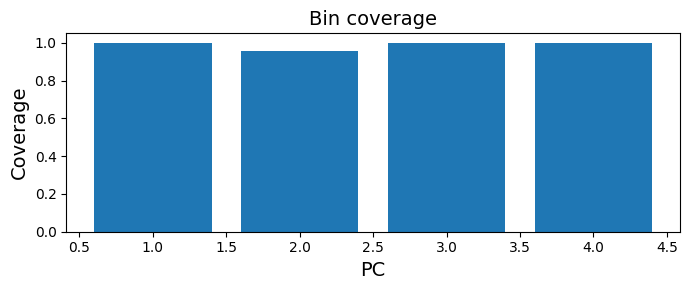

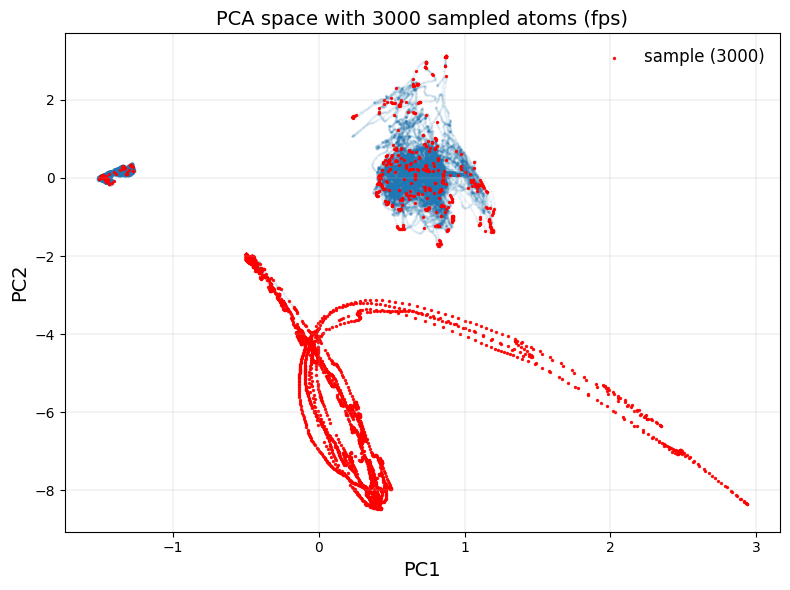

In [10]:
# --- config ---
method = "fps"                  # "grid", "kpp", "kmedoids", "density_fps", "hdbscan"
auto_sampling = True            # True -> stop at target coverage, False -> fixed k
auto_strategy = "seeded"        # "resample" or "seeded"
fixed_k = 50_000                # used if auto_sampling == False
seed = 0
progress = True

# auto params
target_mean_cov = 0.99
coverage_mode = "width"
target_width = 0.10
min_bins = 20
max_bins = 10_000

# resample-mode params
k_start = 100
k_max = 200_000
growth = 1.25
check_every = None

# seeded-batches-mode params
batch = 100
k_max_seeded = 200_000

# --- sampling ---
if auto_sampling:
    if auto_strategy == "seeded":
        print("Using seeded batches auto-sampling strategy")
        idx_atoms, info = sample_to_coverage_seeded_batches(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, batch=batch, k_max=k_max_seeded, seed=seed, progress=progress,
            coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] seeded auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
    else:
        print("Using resample auto-sampling strategy")
        idx_atoms, info = sample_to_coverage(
            X, method=method, target_mean_cov=target_mean_cov,
            k_start=k_start, k_max=k_max, growth=growth, check_every=check_every,
            seed=seed, coverage_mode=coverage_mode, target_width=target_width,
            min_bins=min_bins, max_bins=max_bins, progress=progress
        )
        per_pc, mean_cov, bins_used = info["per_pc"], info["mean_cov"], info["bins_used"]
        print(f"[{method}] resample auto-stop at k={info['k']:,} with mean_cov={mean_cov:.3f}")
else:
    print("Using fixed-k sampling strategy")
    idx_atoms = sample(X, method=method, k=fixed_k, seed=seed, progress=progress)
    per_pc, mean_cov, bins_used = pc_coverage_bins_auto(
        X, idx_atoms, mode=coverage_mode, target_width=target_width,
        min_bins=min_bins, max_bins=max_bins
    )
    print(f"[{method}] fixed k={fixed_k:,} mean_cov={mean_cov:.3f}")

print("Per-PC bins used:", bins_used[:8])
print("Per-PC coverage:", per_pc[:8])

# --- lift to structures ---
chosen_structs = atoms_to_structures(idx_atoms, meta, filemap, choose="all")

# --- save ---
np.save(path_to_results / f"sampled_atom_indices_{method}.npy", idx_atoms)
chosen_structs.to_csv(path_to_results / f"sampled_structures_{method}.csv", index=False)

# --- plot ---
plot_sampling_pca(X, idx_atoms, method=method, per_pc=per_pc, npy_file=npy_file, outdir=path_to_results)

# --- optional export ---
save_files = True
if save_files:
    paths = export_selected_structures(
        chosen_structs, method_name=method.upper(), outdir=path_to_results,
        extra_formats=("xyz",), load_mode="auto"
    )
    print(paths)
